In [82]:
from IPython.display import Markdown, display
title = "Biodex Torque Analysis Pipeline"
authors = "Hugo Duchemin"
display(Markdown(f"# {title}"))
display(Markdown(f"by {authors}"))

# Biodex Torque Analysis Pipeline

by Hugo Duchemin

### 1. Pipeline Objective
The primary goal of this notebook is to quantify **force production accuracy** relative to experimental instructions. We aim to validate whether participants correctly maintained the required intensity levels ($20\%$, $40\%$, and $60\%$ of $MVC_{pre}$) during the contraction blocks.

---

### 2. Analysis Scope
This pipeline focuses exclusively on the **stability and precision** of the produced torque:
* **Intensity Compliance**: Comparison between actual torque output and theoretical targets.
* **Robust Averaging**: Means are calculated across **5 repetitions of 10 seconds** per block to smooth out intra-trial variability.
* **Normalization**: Raw data ($N.m$) is converted into a percentage of the average of the 3 $MVC_{pre}$ trials to allow for inter-subject comparisons.

---

### 3. Deliberate Exclusions
To maintain focus on motor control validation, this analysis **does not include**:
* **Fatigue Analysis**: We are not quantifying performance decline over time or between sessions.
* **Pre vs. Post Comparison**: The analysis is centered on the consistency of the force plateaus during the intensity blocks.

---

### 4. Input & Output Format
* **Input Data**: The raw inputs are force signal files exported from the **Biodex system** (formatted as `.tsv.gz` files following BIDS standards), along with their corresponding event trigger files (`.tsv`).
* **Output Format**: Results are consolidated into a final structured table (`.csv` format) exported to the `results/tableau_futur_analysis_R` directory.

---

## 1. Configuration & Initialisation

To ensure a **flexible and scalable pipeline**, we use a standardized template for subject (`sub`) and session (`ses`) identification. This modular approach allows for seamless switching between participants and sessions by updating only the variables below. 

The file paths are dynamically generated using **f-strings**, ensuring that the data loading process remains consistent across the entire project structure.

To ensure the code runs properly with all necessary libraries, **please execute the cell below**; it will automatically install them if they are not yet available on your system: 

In [83]:
# Ultra-simple library check and installation
import sys

# List of all your needed packages
packages = ["pandas", "numpy", "scipy", "matplotlib", "seaborn"]

for p in packages:
    try:
        __import__(p)
    except ImportError:
        print(f"Installing {p}...")
        !{sys.executable} -m pip install {p}

# Official imports
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

print("✅ All libraries are ready!")

✅ All libraries are ready!


## 2. Data Synchronisation & Signal Overview

#### In this section, the goal is to overlay the experimental triggers (onset of contractions) onto the raw torque data. This check ensure that: 
1. The **sampling frequency** ($500Hz$) is correctly applied.
2. The **triggers** align perfectly with the force production plateaus.
3. There are no **signal offsets** or data gaps for the selected subject and session.

In [84]:
# First let's have an overview on what's the data looklike 
# Load the data from the torque_physio.tsv.gz file
torque_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_physio.tsv.gz', sep='\t', compression='gzip')
events_data = pd.read_csv('/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids/sub-001/ses-001/beh/sub-001_ses-001_task-isometric_recording-torque_events.tsv', sep='\t')
# Display the key information about the data
print (torque_data.head())
print (events_data.head())

   torque_0
0 -0.830475
1 -0.830475
2 -0.254423
3 -0.350431
4 -0.542449
        onset  duration       trial_type
0   68.895262         0  Occlusion_Start
1  369.112185         0    Occlusion_End
2  633.179443         0     Warmup_Start
3  734.497236         0       Warmup_End
4  747.212569         0  Start_MVC_Pre_1


### Observation : We can see 3 headers (onset, duration and trial type) on the event file
- **onset** = precise time of the event (in seconds) 
- **duration** = temporal point (instantanneous) 
- **trial type** = name of the event 

✅ Data successfully loaded for sub-002 | ses-001


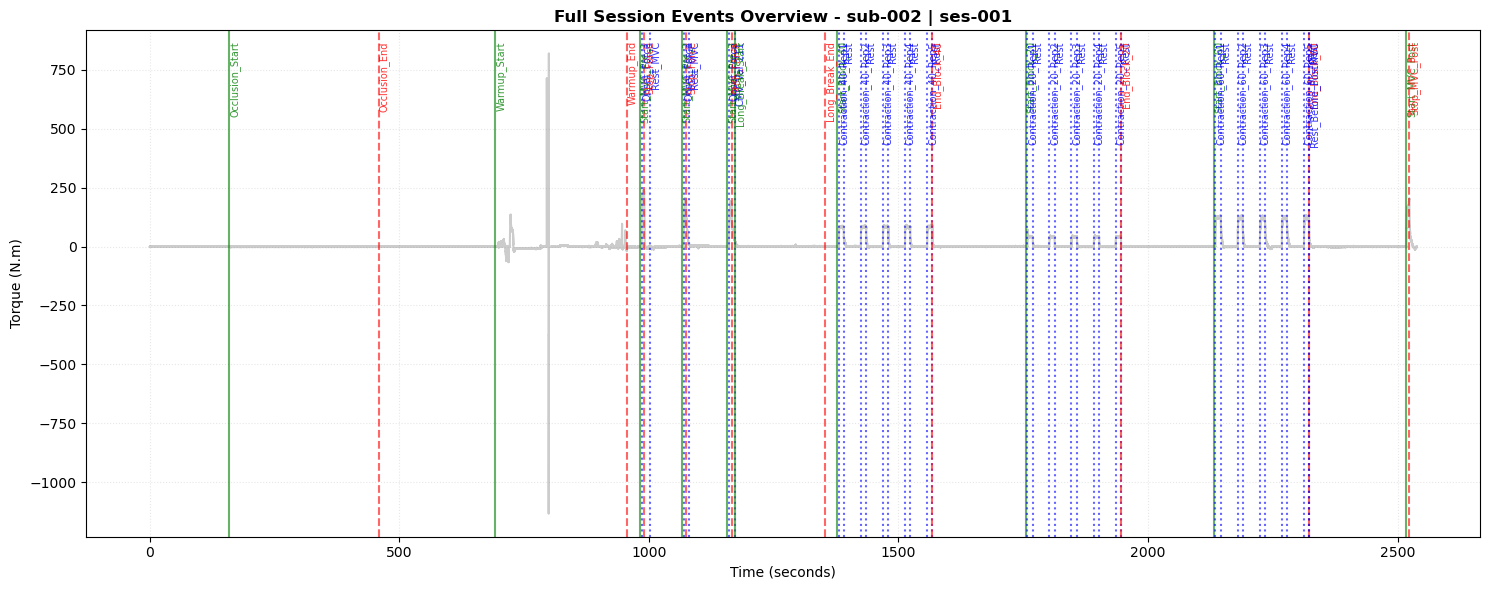

In [85]:
# --- 1. SUBJECT AND SESSION SELECTION ---
# Change these variables to analyze a different participant or session
sub_id = 'sub-002'
ses_id = 'ses-001'

# Base directory path
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
path = f"{base_dir}/{sub_id}/{ses_id}/beh"

# --- 2. AUTOMATED FILE DETECTION & LOADING ---
try:
    # Automatically detect .tsv.gz (torque) and .tsv (events) files for the selected IDs
    torque_path = glob.glob(f"{path}/*torque_physio.tsv.gz")[0]
    events_path = glob.glob(f"{path}/*events.tsv")[0]
    
    torque_data = pd.read_csv(torque_path, sep='\t', compression='gzip')
    events_data = pd.read_csv(events_path, sep='\t')
    
    print(f"✅ Data successfully loaded for {sub_id} | {ses_id}")
except IndexError:
    print(f"❌ Error: Files not found in {path}. Please check sub_id or ses_id.")

# --- 3. SIGNAL PLOTTING & EVENT OVERLAY ---
plt.figure(figsize=(15, 6))

fs = 500  # Sampling frequency (Hz)
time = np.arange(len(torque_data)) / fs  # Time vector in seconds

# Plot the torque signal in gray (background) to make triggers stand out
plt.plot(time, torque_data.iloc[:, 0], label='Torque (N.m)', color='gray', alpha=0.4)

# Iterate through ALL events to overlay triggers
for index, row in events_data.iterrows():
    name = row['trial_type']
    onset = row['onset']
    
    # Dynamic color coding for visual clarity
    if 'Start' in name or 'Occlusion_Start' in name:
        color = 'green'   # Green for starting points
        linestyle = '-'
    elif 'Stop' in name or 'End' in name or 'Stop_Force' in name:
        color = 'red'     # Red for stopping points
        linestyle = '--'
    else:
        color = 'blue'    # Blue for other experimental events
        linestyle = ':'

    # Draw vertical line for the event
    plt.axvline(x=onset, color=color, linestyle=linestyle, alpha=0.6)
    
    # Add event labels at the top of the plot
    plt.text(onset, plt.gca().get_ylim()[1] * 0.95, name, 
             rotation=90, color=color, fontsize=7, verticalalignment='top', alpha=0.8)

plt.xlabel('Time (seconds)')
plt.ylabel('Torque (N.m)')
plt.title(f'Full Session Events Overview - {sub_id} | {ses_id}', fontweight='bold')
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Observation : Signal-Event Alignment Observation
This visualization confirms the successful **overlay** between the raw torque signal and the experimental triggers. 

**Key Notes on the Synchronization:**
* **Comprehensive Validation**: We have deliberately displayed all event markers to ensure no triggers were missing or dropped during the data acquisition process. 
* **Visual Overlap**: While some markers may overlap due to the high density of events in the protocol, this exhaustive view allows us to verify the integrity of the entire session.
* **Selective Filtering**: For subsequent analysis steps (such as MVC calculation or intensity plateaus), these triggers can be selectively filtered to enhance clarity and focus on specific experimental windows.

## 3. MVC analysis & normalization reference

#### Objectives
In this section, we focus on the **Maximum Voluntary Contraction (MVC)** data. The MVC serves two critical purposes in this pipeline:
1. **Normalization Baseline**: We calculate the average of the 3 **Pre-MVC** trials to define the $100\%$ reference. This allows us to normalize the subsequent $20\%$, $40\%$, and $60\%$ intensity blocks.
2. **Fatigue & Performance Monitoring**: By comparing **Pre-MVC** (at the start) and **Post-MVC** (at the end), we can check for:
    * **Fatigue**: A significant drop in torque ($Post < Pre$), indicating the participant's physical state changed during the session.

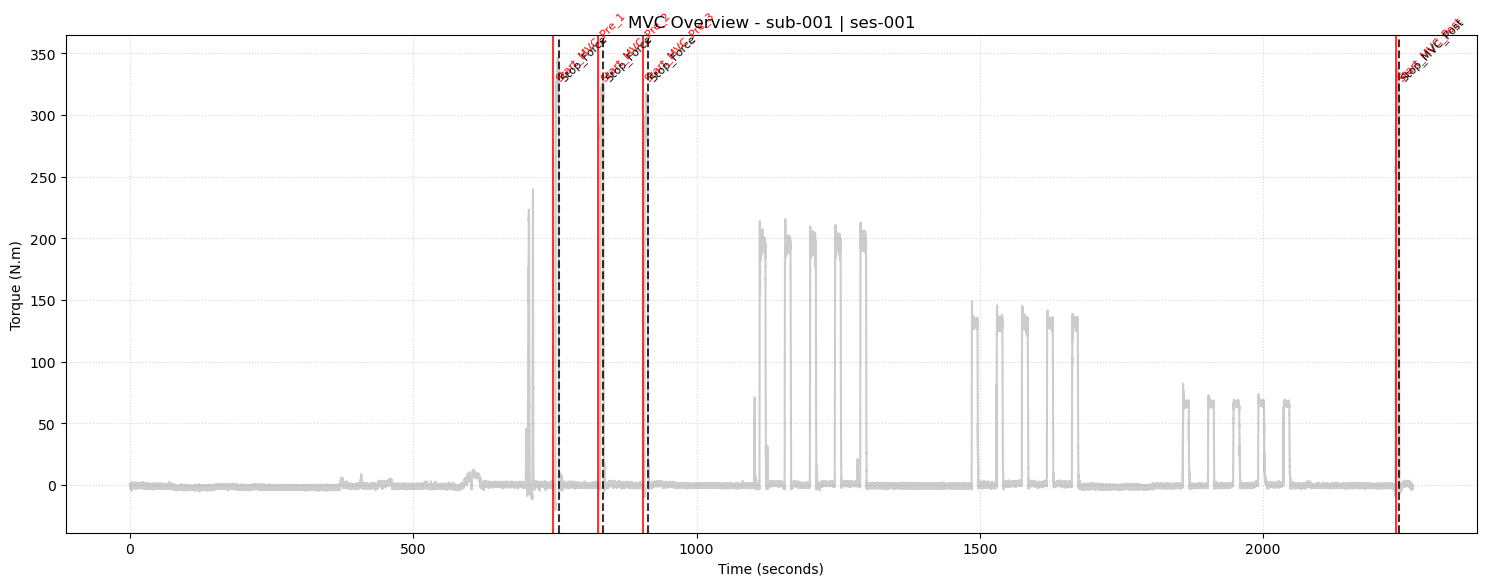

In [86]:
# --- 1. SETTINGS ---
sub_id = 'sub-001'
ses_id = 'ses-001'
fs = 500  # Sampling frequency
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
beh_folder = f"{base_dir}/{sub_id}/{ses_id}/beh"

# Auto-detect the files
torque_files = glob.glob(f"{beh_folder}/*torque_physio.tsv.gz")
events_files = glob.glob(f"{beh_folder}/*events.tsv")

if torque_files and events_files:
    # Load Data
    torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
    events_data = pd.read_csv(events_files[0], sep='\t')
    
    # Re-creating the time vector to avoid errors
    torque_data['time'] = np.arange(len(torque_data)) / fs

    # --- 2. PLOTTING ---
    plt.figure(figsize=(15, 6))

    # Plot the torque signal
    plt.plot(torque_data['time'], torque_data.iloc[:, 0], label='Torque (N.m)', color='gray', alpha=0.4)

    # Plot event markers
    for index, row in events_data.iterrows():
        name = row['trial_type']
        onset = row['onset']
        
        # Check for MVC starts and any stops
        is_start = 'Start_MVC' in name
        is_stop = 'Stop_Force' in name or 'Stop_MVC_Post' in name
        
        if is_start or is_stop:
            color = 'red' if is_start else 'black'
            linestyle = '-' if is_start else '--'
            
            plt.axvline(x=onset, color=color, linestyle=linestyle, alpha=0.8)
            
            # Use the current maximum of the plot to place the text label
            plt.text(onset, plt.gca().get_ylim()[1] * 0.9, name, rotation=45, color=color, fontsize=8)

    # --- FIX FOR THE VERTICAL AXIS (Optional but recommended) ---
    # This line ensures the graph focuses on positive torque if you have negative noise
    # plt.ylim(bottom=-5) 

    plt.xlabel('Time (seconds)')
    plt.ylabel('Torque (N.m)')
    plt.title(f'MVC Overview - {sub_id} | {ses_id}')
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

else:
    print(f"Error: Could not find files for {sub_id} in {ses_id}")

## 4. MVC quantification & Baseline calculation

### The goal of this section is to extract a stable maximum torque value for each MVC trial. Rather than using a single instantaneous peak, which can be sensitive to signal noise or artifacts, we use a **3-second sliding window** centered around the maximum value.

### Methodology
For each MVC trial identified in the previous step (Pre-MVC 1, 2, 3 and Post-MVC):
1. **Windowing**: We isolate the torque signal between the `Start_MVC` and `Stop_Force` triggers.
2. **Smoothing & Peak Detection**: We identify the maximum torque point within this trial.
3. **3-Second Averaging**: We calculate the mean torque over a **3-second interval** (1.5s before and 1.5s after the peak).
4. **Final Baseline**: The average of the three **Pre-MVC** trials is calculated to serve as the $100\%$ reference for the rest of the session.

✅ Processing: sub-001 | ses-001


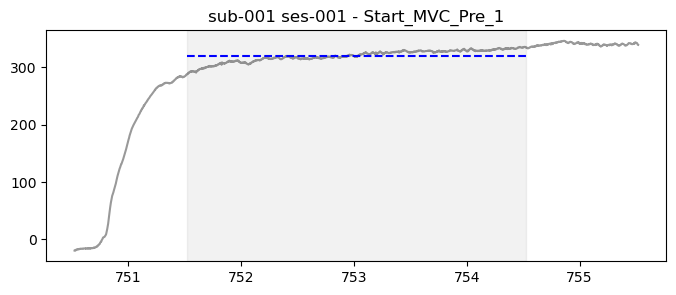

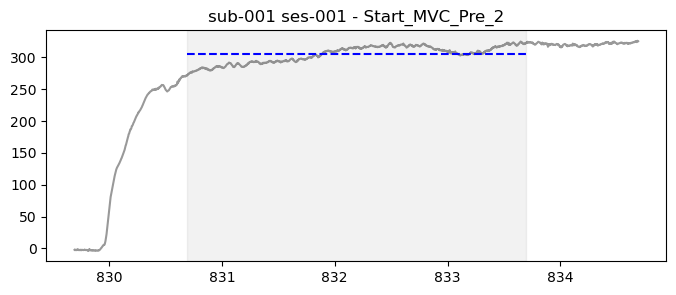

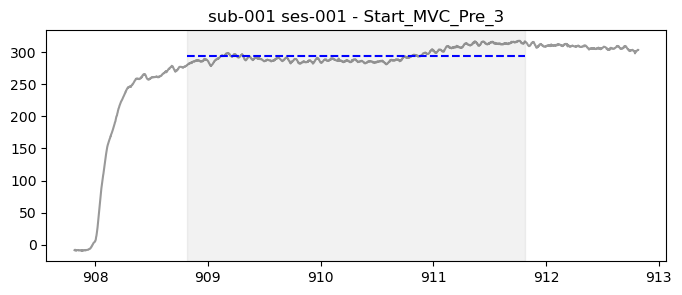

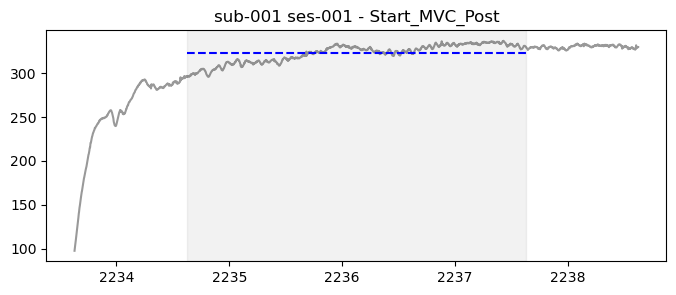

✅ Processing: sub-001 | ses-002


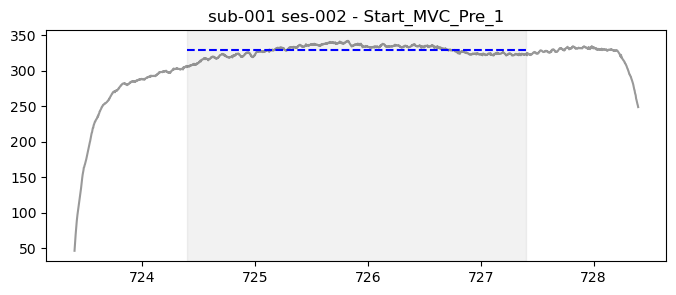

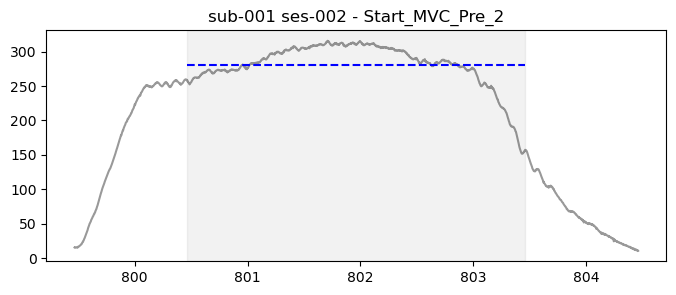

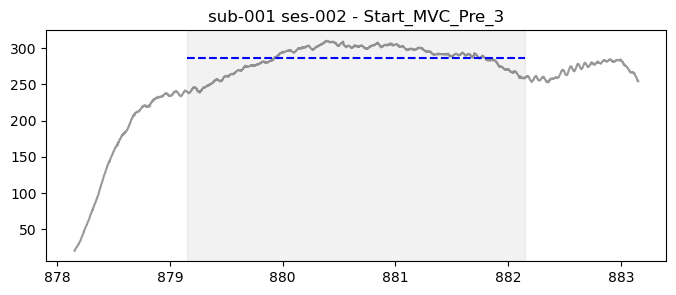

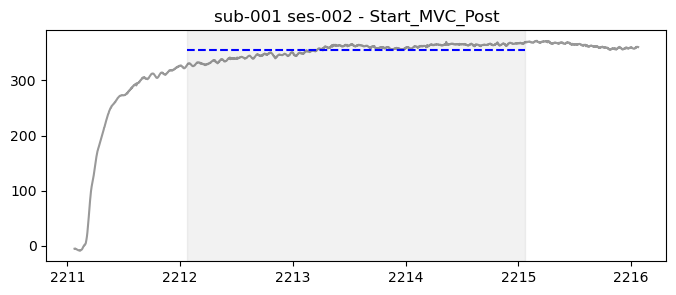

✅ Processing: sub-002 | ses-001


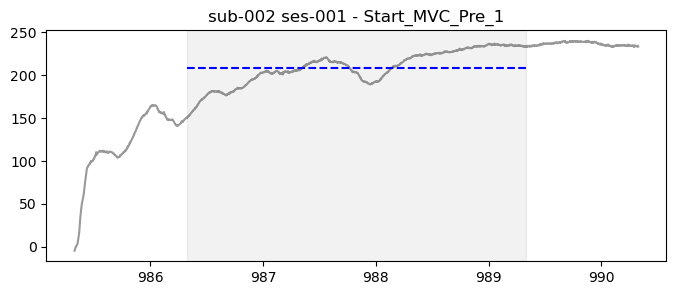

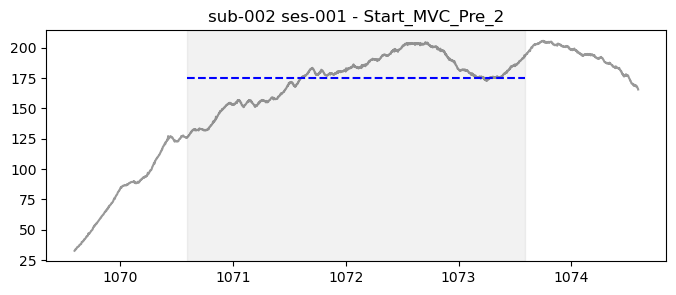

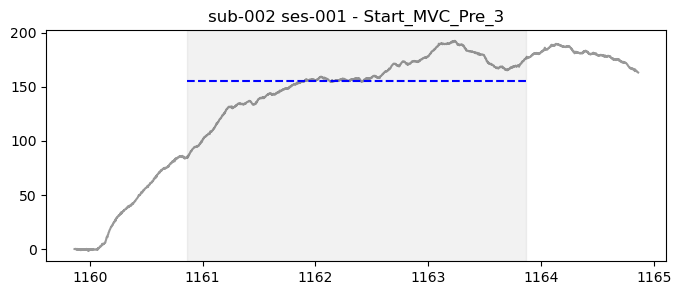

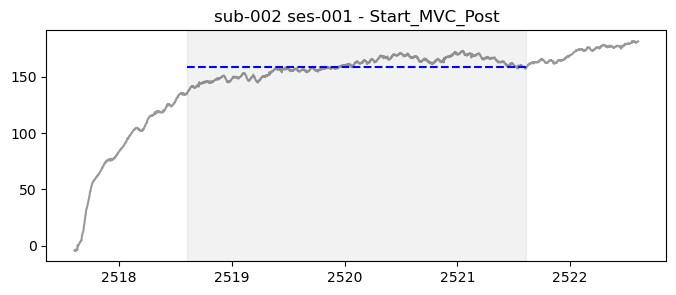

✅ Processing: sub-002 | ses-002


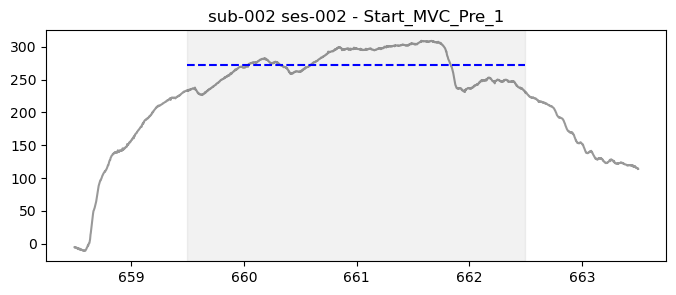

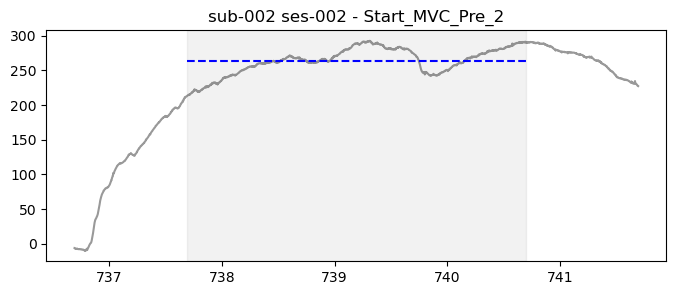

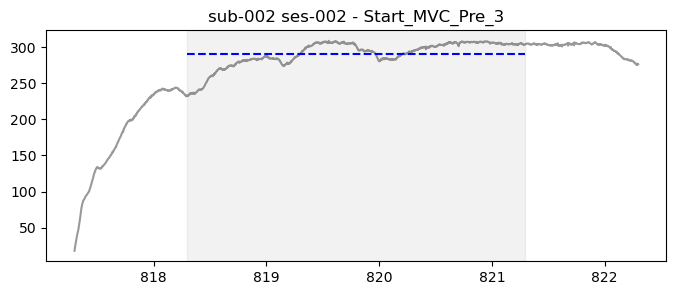

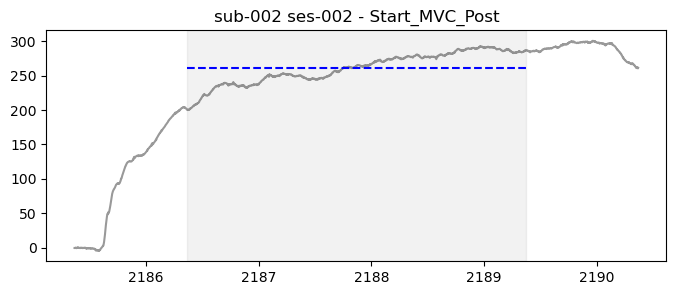

✅ Processing: sub-003 | ses-001


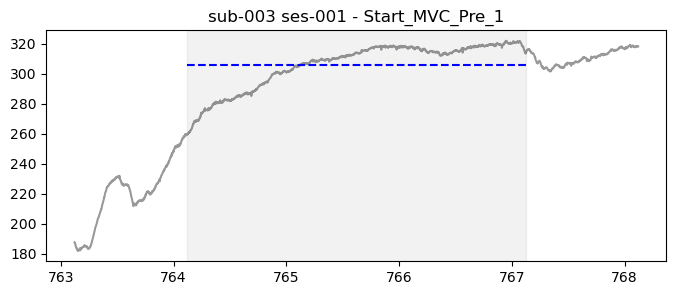

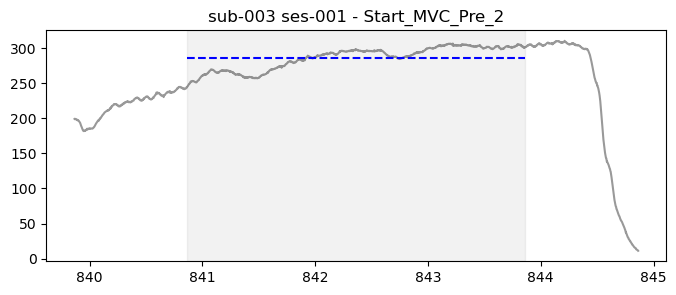

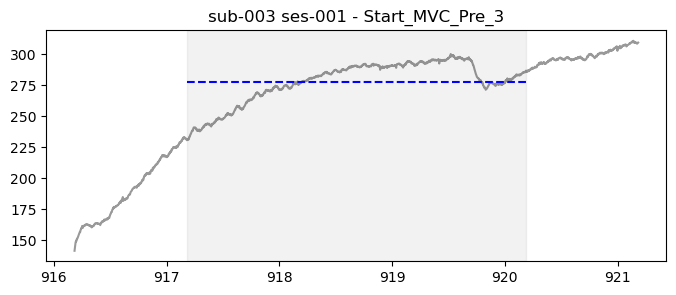

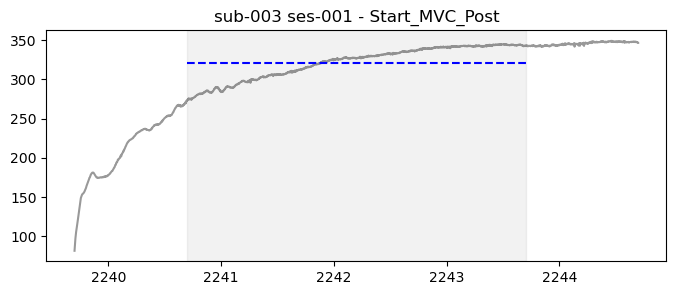

✅ Processing: sub-003 | ses-002


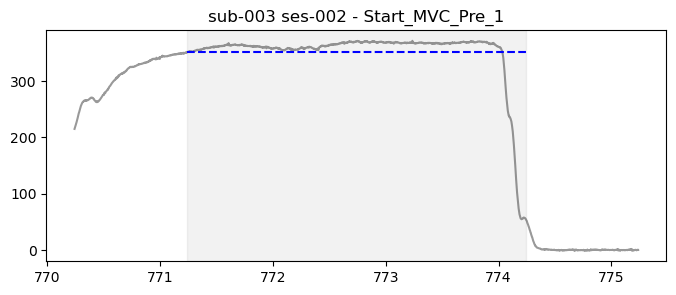

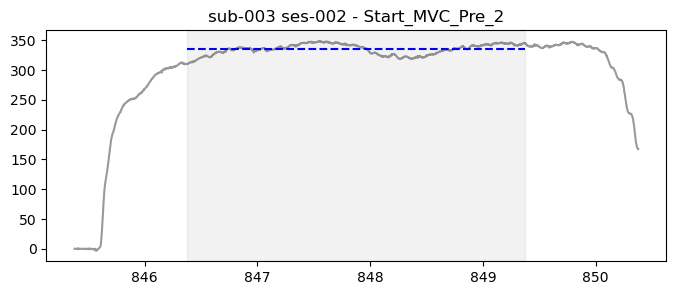

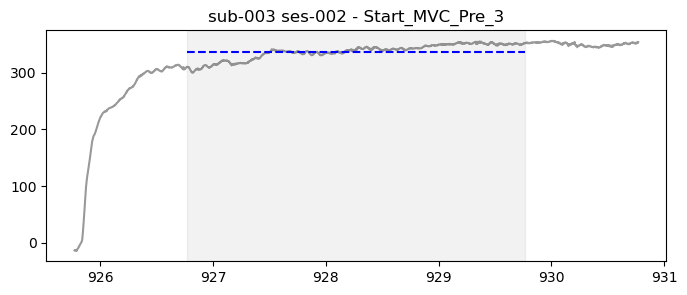

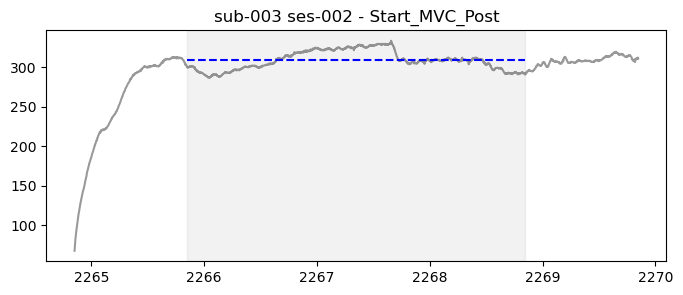


--- GLOBAL SUMMARY TABLE ---
    Subject  Session              MVC  Peak_Global     Mean_3s
0   sub-001  ses-001  Start_MVC_Pre_1   346.175010  319.849900
1   sub-001  ses-001  Start_MVC_Pre_2   326.032196  304.655395
2   sub-001  ses-001  Start_MVC_Pre_3   317.594547  294.626362
3   sub-001  ses-001   Start_MVC_Post   336.689115  322.315909
4   sub-001  ses-002  Start_MVC_Pre_1   342.254486  328.777344
5   sub-001  ses-002  Start_MVC_Pre_2   315.627714  280.614151
6   sub-001  ses-002  Start_MVC_Pre_3   310.128687  286.045388
7   sub-001  ses-002   Start_MVC_Post   371.690794  354.500009
8   sub-002  ses-001  Start_MVC_Pre_1   239.914351  208.784479
9   sub-002  ses-001  Start_MVC_Pre_2   205.868444  175.160380
10  sub-002  ses-001  Start_MVC_Pre_3   192.558099  155.760825
11  sub-002  ses-001   Start_MVC_Post   181.962815  159.081427
12  sub-002  ses-002  Start_MVC_Pre_1   309.033106  271.720517
13  sub-002  ses-002  Start_MVC_Pre_2   292.476746  263.681381
14  sub-002  ses-002  Sta

In [87]:
# --- 1. USER SELECTION ---
# Add all subjects and sessions you want to analyze here
subjects = ['sub-001', 'sub-002', 'sub-003'] 
sessions = ['ses-001', 'ses-002']

fs = 500            # Sampling frequency
cutoff = 200        # Cut-off frequency for noise reduction
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'

# --- 2. FILTERING FUNCTION ---
def lowpass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# List to collect all results before converting to DataFrame
all_mvc_results = []

# --- 3. NESTED LOOP (Subjects & Sessions) ---
for sub_id in subjects:
    for ses_id in sessions:
        path = f"{base_dir}/{sub_id}/{ses_id}/beh"
        
        # Check if files exist
        torque_files = glob.glob(f"{path}/*torque_physio.tsv.gz")
        events_files = glob.glob(f"{path}/*events.tsv")
        
        if not torque_files or not events_files:
            print(f"⚠️ Skipping: Files not found for {sub_id} | {ses_id}")
            continue
            
        print(f"✅ Processing: {sub_id} | {ses_id}")
        
        try:
            # Load Data
            torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
            events_data = pd.read_csv(events_files[0], sep='\t')
            torque_data['time'] = np.arange(len(torque_data)) / fs
            
            # Apply Filter
            torque_data.iloc[:, 0] = lowpass_filter(torque_data.iloc[:, 0], cutoff, fs)

            # --- 4. MVC ANALYSIS PER SESSION ---
            mvc_labels = ['Start_MVC_Pre_1', 'Start_MVC_Pre_2', 'Start_MVC_Pre_3', 'Start_MVC_Post']
            
            for label in mvc_labels:
                try:
                    # Find start event
                    idx_label = events_data.index[events_data['trial_type'] == label][0]
                    t_start_event = events_data.loc[idx_label, 'onset']
                    
                    # Look for Onset_Force
                    following_events = events_data.iloc[idx_label:]
                    onset_force_list = following_events[following_events['trial_type'] == 'Onset_Force']
                    t_reference = onset_force_list.iloc[0]['onset'] if not onset_force_list.empty else t_start_event

                    # Windows
                    t_end_5s = min(t_reference + 5, torque_data['time'].max())
                    segment_5s = torque_data[(torque_data['time'] >= t_reference) & (torque_data['time'] <= t_end_5s)].copy()
                    
                    t_mean_start, t_mean_end = t_reference + 1.0, t_reference + 4.0
                    
                    if t_mean_end > segment_5s['time'].max():
                        t_mean_end = segment_5s['time'].max()
                        t_mean_start = max(t_reference, t_mean_end - 3.0)

                    segment_3s = segment_5s[(segment_5s['time'] >= t_mean_start) & (segment_5s['time'] <= t_mean_end)].copy()
                    
                    # Calculations
                    peak_5s_val = segment_5s.iloc[:, 0].max()
                    peak_5s_time = segment_5s.loc[segment_5s.iloc[:, 0].idxmax(), 'time']
                    mean_3s_val = segment_3s.iloc[:, 0].mean()
                    
                    # Append to master list
                    all_mvc_results.append({
                        'Subject': sub_id, 'Session': ses_id, 'MVC': label, 
                        'Peak_Global': peak_5s_val, 'Mean_3s': mean_3s_val
                    })
                    
                    # Visual (Optional: comment out if analyzing too many subjects)
                    plt.figure(figsize=(8, 3))
                    plt.plot(segment_5s['time'], segment_5s.iloc[:, 0], color='black', alpha=0.4)
                    plt.axvspan(t_mean_start, t_mean_end, color='gray', alpha=0.1)
                    plt.hlines(mean_3s_val, t_mean_start, t_mean_end, colors='blue', linestyles='--')
                    plt.title(f"{sub_id} {ses_id} - {label}")
                    plt.show()

                except Exception as e:
                    print(f"⚠️ Error on {label} for {sub_id} {ses_id}: {e}")

        except Exception as e:
            print(f"❌ Critical error on {sub_id} {ses_id}: {e}")

# --- 5. GLOBAL ACCUMULATION ---
# Creating the final DataFrame from all collected results
df_final = pd.DataFrame(all_mvc_results)

print("\n--- GLOBAL SUMMARY TABLE ---")
print(df_final)

## 5. Checking fatigue : Pre vs Post MVC comparison

# V. Fatigue Assessment: Pre vs. Post MVC Comparison

### Objectives
The primary goal of this section is to quantify the **Neuromuscular Fatigue** induced by the experimental protocol. By comparing the maximal force capacity at the beginning and the end of the session, we can determine if the submaximal contraction blocks led to a significant decrease in performance.

### Analysis Dependency - Critical Note
> **Please Note:** This analysis is strictly dependent on the data processed in **Step 4**. It relies on the global table `df_final`. 
> 
> **Important**: If you change the subject (`sub_id`) or session (`ses_id`), you **MUST** re-run the Step IV analysis cell first. This ensures the fatigue calculation is performed on the correct participant's data and not on the previous one stored in memory.

### Metrics & Indicators
We will calculate two main indicators:
1. **Mean Pre-MVC**: The average of the three initial maximal trials, used as the "Fresh" baseline ($100\%$).
2. **MVC Decay (Fatigue Index %)**: The percentage of force loss calculated as:
$$Fatigue\ Loss\ (\%) = \left( \frac{Mean\ Pre\ MVC - Post\ MVC}{Mean\ Pre\ MVC} \right) \times 100$$

### Interpretations
* **Significant Fatigue ($> 15\%$ drop)**: Suggests that the intensity blocks were strenuous enough to induce peripheral or central fatigue.
* **Stability ($< 5\%$ change)**: Indicates that the participant maintained their force capacity throughout the task, ensuring that the submaximal trials were likely not affected by exhaustion.

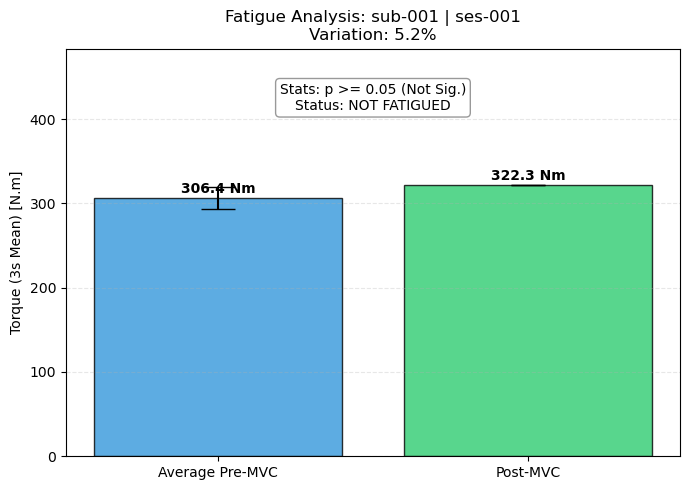

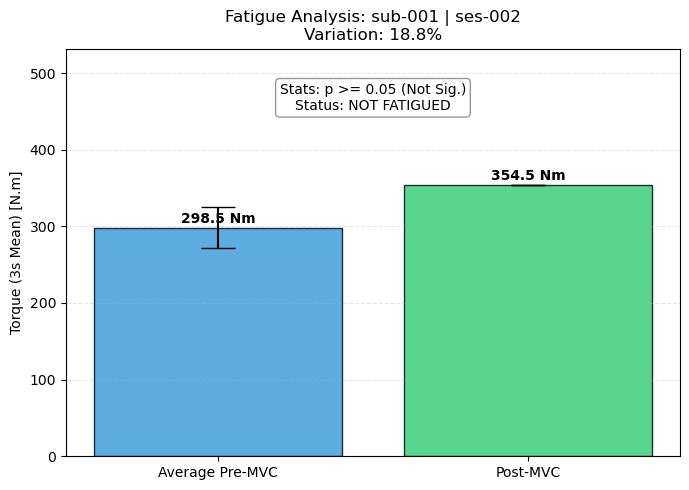

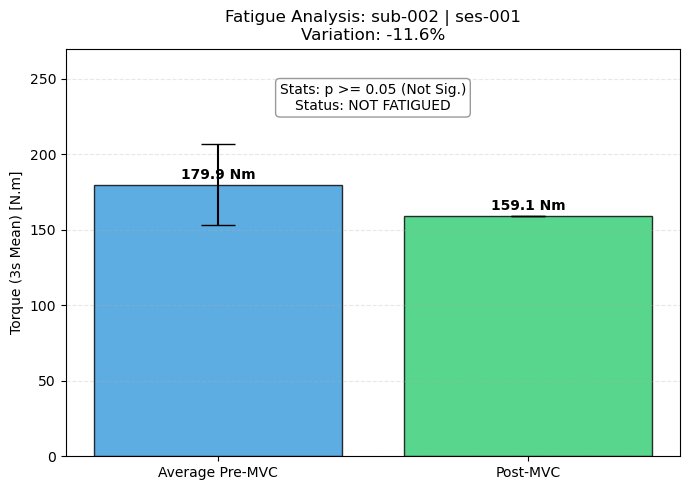

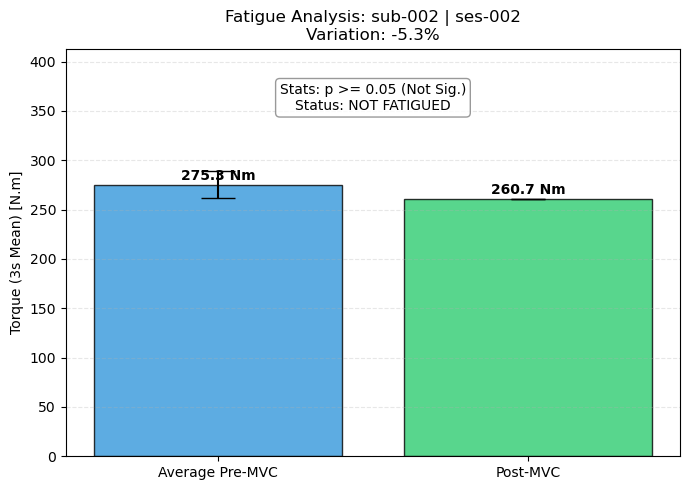

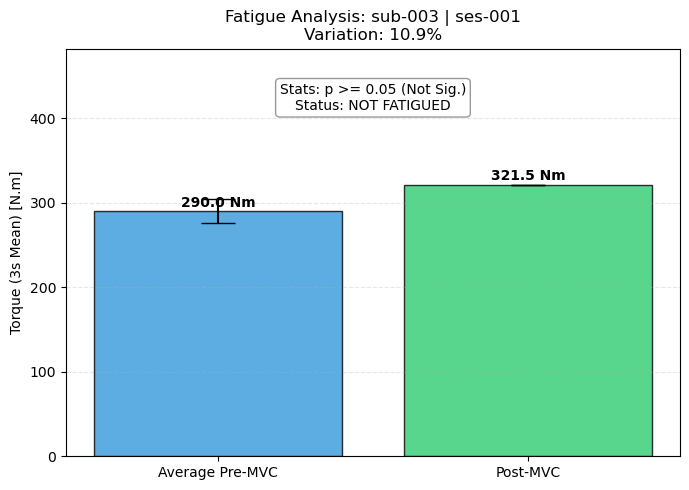

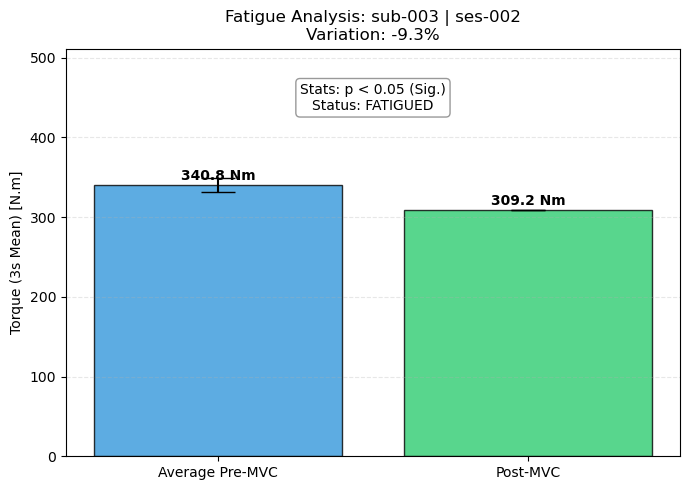


--- GLOBAL FATIGUE SUMMARY ---


,Subject,Session,Pre_Avg,Post,Change_%,p-value,Status
0,sub-001,ses-001,306.38,322.32,5.20,0.1618,NOT FATIGUED
1,sub-001,ses-002,298.48,354.50,18.77,0.0666,NOT FATIGUED
2,sub-002,ses-001,179.90,159.08,-11.57,0.3111,NOT FATIGUED
3,sub-002,ses-002,275.29,260.75,-5.28,0.2084,NOT FATIGUED
4,sub-003,ses-001,289.97,321.49,10.87,0.0628,NOT FATIGUED
5,sub-003,ses-002,340.77,309.19,-9.27,0.0246,FATIGUED


In [88]:
# --- 1. USER SELECTION ---
subjects_to_plot = ['sub-001', 'sub-002', 'sub-003']
sessions_to_plot = ['ses-001', 'ses-002']

fatigue_results_list = []

# --- 2. DATA EXTRACTION & VALIDATION ---
if 'df_final' in locals() and not df_final.empty:
    
    for current_sub in subjects_to_plot:
        for current_ses in sessions_to_plot:
            
            # Filtering df_final
            current_analysis = df_final[(df_final['Subject'] == current_sub) & 
                                        (df_final['Session'] == current_ses)]

            pre_data = current_analysis[current_analysis['MVC'].str.contains('Pre')]
            post_data = current_analysis[current_analysis['MVC'].str.contains('Post')]

            if len(pre_data) == 3 and len(post_data) == 1:
                pre_means = pre_data['Mean_3s'].values
                post_mean = post_data['Mean_3s'].values[0]

                # --- 3. CALCULATIONS ---
                group_pre_avg = np.mean(pre_means)
                group_pre_std = np.std(pre_means, ddof=1)
                percentage_change = ((post_mean - group_pre_avg) / group_pre_avg) * 100
                
                # One-sample t-test
                t_stat, p_val = stats.ttest_1samp(pre_means, post_mean)
                
                # Diagnostic logic (for text only)
                is_significant = p_val < 0.05
                status = "FATIGUED" if (is_significant and percentage_change < 0) else "NOT FATIGUED"

                # Save to summary list
                fatigue_results_list.append({
                    'Subject': current_sub, 'Session': current_ses,
                    'Pre_Avg': round(group_pre_avg, 2), 'Post': round(post_mean, 2),
                    'Change_%': round(percentage_change, 2), 'p-value': round(p_val, 4),
                    'Status': status
                })

                # --- 4. VISUALIZATION ---
                plt.figure(figsize=(7, 5))
                labels = ['Average Pre-MVC', 'Post-MVC']
                values = [group_pre_avg, post_mean]
                errors = [group_pre_std, 0]
                
                # FIXED COLORS: Pre = Blue (#3498db), Post = Green (#2ecc71)
                colors = ['#3498db', '#2ecc71']
                
                bars = plt.bar(labels, values, yerr=errors, capsize=12, color=colors, edgecolor='black', alpha=0.8)
                
                # Add Nm labels on bars
                for bar in bars:
                    height = bar.get_height()
                    plt.text(bar.get_x() + bar.get_width()/2., height + 2, f'{height:.1f} Nm', 
                             ha='center', va='bottom', fontweight='bold')

                # Annotation box for stats and status
                sig_text = "p < 0.05 (Sig.)" if is_significant else "p >= 0.05 (Not Sig.)"
                plt.annotate(f'Stats: {sig_text}\nStatus: {status}', 
                             xy=(0.5, 0.85), xycoords='axes fraction', ha='center',
                             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

                plt.ylabel('Torque (3s Mean) [N.m]')
                plt.title(f'Fatigue Analysis: {current_sub} | {current_ses}\nVariation: {percentage_change:.1f}%')
                plt.ylim(0, max(values) * 1.5)
                plt.grid(axis='y', linestyle='--', alpha=0.3)
                plt.tight_layout()
                plt.show()

            else:
                print(f"⚠️ Data not found for {current_sub} | {current_ses} in df_final.")

    # --- 5. FINAL SUMMARY TABLE ---
    if fatigue_results_list:
        summary_fatigue_df = pd.DataFrame(fatigue_results_list)
        print("\n--- GLOBAL FATIGUE SUMMARY ---")
        display(summary_fatigue_df)
        
else:
    print("❌ ERROR: df_final not found. Please run the MVC Analysis (Step 4) loop first.")

#### **Observation** : We can observe on this comparison between the 3 participants and the two sessions/participant that during his second session, the third participant show some fatigue (-9.26%). Given our small sub-sample size (n=3) relative to the total sample (n=20) in our "real study", we anticipate that this level of fatigue will become non-significant once the full analysis will be conducted.

## 6. Submaximal Intensities Analysis (20%, 40%, 60%)

### Objectives
The goal of this section is to verify the **accuracy** of the participant's contractions during the submaximal blocks. We aim to determine if the torque produced effectively matches the theoretical targets calculated from the initial baseline (Pre-MVC).

### Methodology
For each intensity level (20%, 40%, and 60% of MVC), we perform the following steps:
1. **Target Calculation**: The theoretical target is defined for each session as:
$$Target\ (N.m) = \text{Mean Pre-MVC} \times \text{Intensity \%}$$
2. **Steady-State Extraction**: We isolate the torque signal during the execution of each submaximal block.
3. **Accuracy Metric**:
    * **Mean Produced Torque**: We calculate the average force maintained by the participant during the plateau phase of the contraction.
    * **Target Gap**: Difference (in N.m and %) between the target and the actual performance.

### Interpretations
* **Accurate Performance**: The produced torque is close to the target, validating that the participant correctly interpreted the visual or verbal cues.

✅ sub-001 | ses-001 processed successfully.
✅ sub-002 | ses-001 processed successfully.
✅ sub-003 | ses-001 processed successfully.
✅ sub-001 | ses-002 processed successfully.
✅ sub-002 | ses-002 processed successfully.
✅ sub-003 | ses-002 processed successfully.


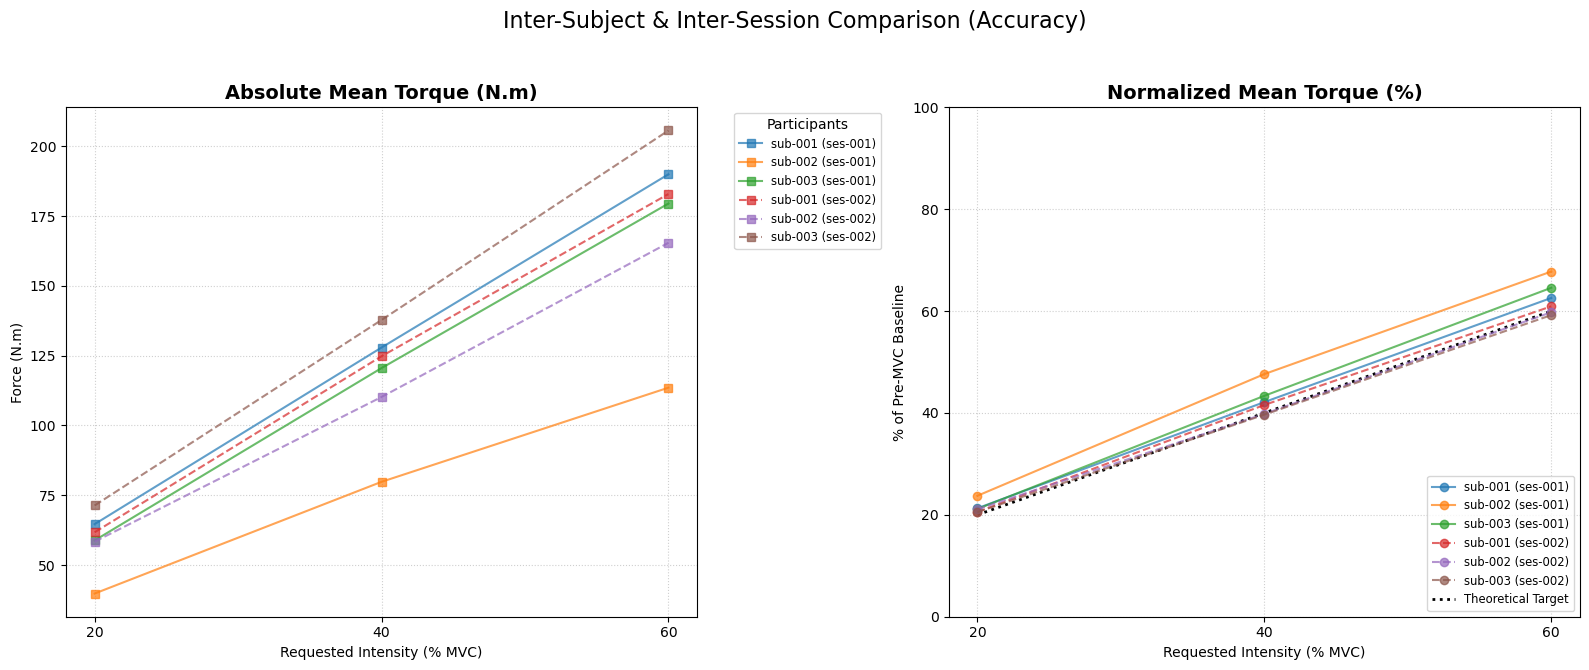

In [89]:
# --- 1. CONFIGURATION ---
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
sessions_to_analyze = ['ses-001', 'ses-002'] 
fs = 500 
intensities = [20, 40, 60]

# List to store results for all subjects and sessions
all_data = []

# --- 2. MULTI-SESSION & MULTI-SUBJECT LOOP ---
subject_dirs = sorted(glob.glob(os.path.join(base_dir, 'sub-*')))

for ses_id in sessions_to_analyze:
    for sub_path in subject_dirs:
        sub_id = os.path.basename(sub_path)
        beh_folder = os.path.join(sub_path, ses_id, 'beh')
        
        torque_files = glob.glob(f"{beh_folder}/*torque_physio.tsv.gz")
        events_files = glob.glob(f"{beh_folder}/*events.tsv")

        if torque_files and events_files:
            try:
                # Loading data
                torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
                events_data = pd.read_csv(events_files[0], sep='\t')
                torque_data['time'] = np.arange(len(torque_data)) / fs
                torque_signal = torque_data.iloc[:, 0]

                # A. Pre-MVC Baseline Calculation
                mvc_pre_events = events_data[events_data['trial_type'].str.contains('Start_MVC_Pre', na=False)]
                mvc_pre_peaks = []
                for _, row in mvc_pre_events.iterrows():
                    mask = (torque_data['time'] >= row['onset']) & (torque_data['time'] <= row['onset'] + 5)
                    if any(mask):
                        mvc_pre_peaks.append(torque_signal[mask].max())
                
                if not mvc_pre_peaks:
                    continue
                mean_mvc_pre = np.mean(mvc_pre_peaks)

                # B. Submaximal Means Calculation
                sub_means_nm = []
                for target in intensities:
                    reps = events_data[events_data['trial_type'].str.contains(f'Contraction_{target}_Rep', na=False)]
                    rep_vals = []
                    for _, row in reps.iterrows():
                        mask = (torque_data['time'] >= row['onset']) & (torque_data['time'] <= row['onset'] + 10)
                        if any(mask):
                            rep_vals.append(torque_signal[mask].mean())
                    sub_means_nm.append(np.mean(rep_vals) if rep_vals else 0)

                # Store processed results with session ID
                all_data.append({
                    'sub': sub_id,
                    'ses': ses_id,
                    'nm': sub_means_nm,
                    'percent': [(val / mean_mvc_pre) * 100 for val in sub_means_nm]
                })
                print(f"✅ {sub_id} | {ses_id} processed successfully.")
                
            except Exception as e:
                print(f"❌ Error processing {sub_id} | {ses_id}: {e}")

# --- 3. GLOBAL VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define line styles for sessions
session_styles = {'ses-001': '-', 'ses-002': '--'}

for data in all_data:
    label_text = f"{data['sub']} ({data['ses']})"
    style = session_styles.get(data['ses'], '-')
    
    # Plot 1: Absolute Torque (N.m)
    ax1.plot(intensities, data['nm'], marker='s', label=label_text, 
             linestyle=style, alpha=0.7, linewidth=1.5)
    
    # Plot 2: Normalized Torque (%)
    ax2.plot(intensities, data['percent'], marker='o', label=label_text, 
             linestyle=style, alpha=0.7, linewidth=1.5)

# Plot 1 Styling
ax1.set_title('Absolute Mean Torque (N.m)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Force (N.m)')
ax1.set_xlabel('Requested Intensity (% MVC)')
ax1.set_xticks(intensities)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Participants", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Plot 2 Styling
ax2.plot([20, 40, 60], [20, 40, 60], color='black', linestyle=':', linewidth=2, label='Theoretical Target', zorder=1)
ax2.set_title('Normalized Mean Torque (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('% of Pre-MVC Baseline')
ax2.set_xlabel('Requested Intensity (% MVC)')
ax2.set_xticks(intensities)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right', fontsize='small')

plt.suptitle(f'Inter-Subject & Inter-Session Comparison (Accuracy)', fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# VII. Data Export for Statistical Analysis (Python to R)

### Objectives
The primary goal of this section is to consolidate all processed metrics—**MVC values, Fatigue indices, and Submaximal accuracy**—into a single, structured dataset. This "Master File" serves as the bridge between signal processing (Python) and advanced futur statistical modeling (R).

### Methodology
We aggregate data from previous sections into a **Tidy Data** format. The exported file includes:
1. **Metadata**: Subject ID and Session ID.
2. **Fatigue Metrics**: Pre-MVC baseline, Post-MVC values, and percentage of change.
3. **Accuracy Metrics**: Mean torque produced at 20%, 40%, and 60% of MVC.

### Future Statistical Perspectives (not the subject for this work)
Beyond descriptive statistics, this structured dataset is designed to support my upcoming analyses in R:
* **Distribution & Normality**: Assessing data distribution to choose between parametric and non-parametric tests.
* **Reliability & Agreement**: Utilizing the two sessions to perform **Bland-Altman** plots (to visualize agreement) and calculate **Intraclass Correlation Coefficients (ICC)** to evaluate the test-retest reliability of the measurements.

### Export Format
* **Format**: Comma-Separated Values (`.csv`)

In [90]:
# --- 1. PATH CONFIGURATION ---
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
results_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/results'
sub_folder_name = "tableau_futur_analysis_R"
final_output_path = os.path.join(results_dir, sub_folder_name)

if not os.path.exists(final_output_path):
    os.makedirs(final_output_path)
    print(f"Directory created: {final_output_path}")

output_filename = os.path.join(final_output_path, 'torque_summary_R.csv')

# --- 2. ANALYSIS PARAMETERS ---
fs = 500 
intensities = [20, 40, 60]
contraction_duration = 10 
mvc_duration = 5

export_data = []

# --- 3. DATA PROCESSING ---
subject_dirs = sorted(glob.glob(os.path.join(base_dir, 'sub-*')))

print("Starting extraction for Subject, Session, Condition, Intensity Mean, and MVC Pre...")

for sub_path in subject_dirs:
    sub_id = os.path.basename(sub_path)
    session_paths = sorted(glob.glob(os.path.join(sub_path, 'ses-*')))
    
    for ses_path in session_paths:
        ses_id = os.path.basename(ses_path)
        beh_folder = os.path.join(ses_path, 'beh')
        
        torque_files = glob.glob(f"{beh_folder}/*torque_physio.tsv.gz")
        events_files = glob.glob(f"{beh_folder}/*events.tsv")

        if torque_files and events_files:
            try:
                torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
                events_data = pd.read_csv(events_files[0], sep='\t')
                torque_data['time'] = np.arange(len(torque_data)) / fs
                torque_signal = torque_data.iloc[:, 0]

                # A. CALCULATE MVC PRE MEAN (Reference)
                mvc_pre_events = events_data[events_data['trial_type'].str.contains('Start_MVC_Pre', na=False)]
                pre_peaks = []
                for _, row in mvc_pre_events.iterrows():
                    mask = (torque_data['time'] >= row['onset']) & (torque_data['time'] <= row['onset'] + mvc_duration)
                    if any(mask):
                        pre_peaks.append(torque_signal[mask].max())
                
                mean_mvc_pre = np.mean(pre_peaks) if pre_peaks else np.nan

                # B. CALCULATE MEAN FOR EACH INTENSITY CONDITION
                for target in intensities:
                    reps = events_data[events_data['trial_type'].str.contains(f'Contraction_{target}_Rep', na=False)]
                    
                    if not reps.empty:
                        rep_means = []
                        for _, row in reps.iterrows():
                            mask = (torque_data['time'] >= row['onset']) & (torque_data['time'] <= row['onset'] + contraction_duration)
                            if any(mask):
                                rep_means.append(torque_signal[mask].mean())
                        
                        avg_produced = np.mean(rep_means) if rep_means else np.nan
                        
                        # Add the requested columns
                        export_data.append({
                            'Subject': sub_id,
                            'Session': ses_id,
                            'Condition': f'{target}%',
                            'Mean_Intensity_Nm': round(avg_produced, 3),
                            'MVC_Pre_Mean': round(mean_mvc_pre, 3)
                        })
                        
            except Exception as e:
                print(f"❌ Error on {sub_id} {ses_id}: {e}")

# --- 4. EXPORT TO CSV ---
df_export = pd.DataFrame(export_data)

if not df_export.empty:
    # Exporting with ';' for Excel compatibility and '.' for R decimals
    df_export.to_csv(output_filename, index=False, sep=';', decimal='.') 
    print("-" * 50)
    print(f"✅ Export successful!")
    print(f"📂 File: {output_filename}")
    print("-" * 50)
    display(df_export.head())
else:
    print("⚠️ No data found.")

Starting extraction for Subject, Session, Condition, Intensity Mean, and MVC Pre...
--------------------------------------------------
✅ Export successful!
📂 File: /Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/results/tableau_futur_analysis_R/torque_summary_R.csv
--------------------------------------------------


,Subject,Session,Condition,Mean_Intensity_Nm,MVC_Pre_Mean
0,sub-001,ses-001,20%,64.642,303.561
1,sub-001,ses-001,40%,127.907,303.561
2,sub-001,ses-001,60%,189.977,303.561
3,sub-001,ses-002,20%,61.739,300.161
4,sub-001,ses-002,40%,124.789,300.161



--- NORMALITY TESTS ON GROUP MEANS (SHAPIRO-WILK) ---
Session Intensity  N_Subjects  p-value Normal
ses-001       20%           3   0.4321    Yes
ses-001       40%           3   0.2721    Yes
ses-001       60%           3   0.2422    Yes
ses-002       20%           3   0.4823    Yes
ses-002       40%           3   0.9360    Yes
ses-002       60%           3   0.8556    Yes


/var/folders/jk/klwmglyd3393trh46z_lrl380000gq/T/ipykernel_8318/3873678754.py:79: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.3'` for the same effect.

  sns.stripplot(x='Intensity', y='Torque', hue='Session', data=df_group,
/var/folders/jk/klwmglyd3393trh46z_lrl380000gq/T/ipykernel_8318/3873678754.py:79: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='Intensity', y='Torque', hue='Session', data=df_group,


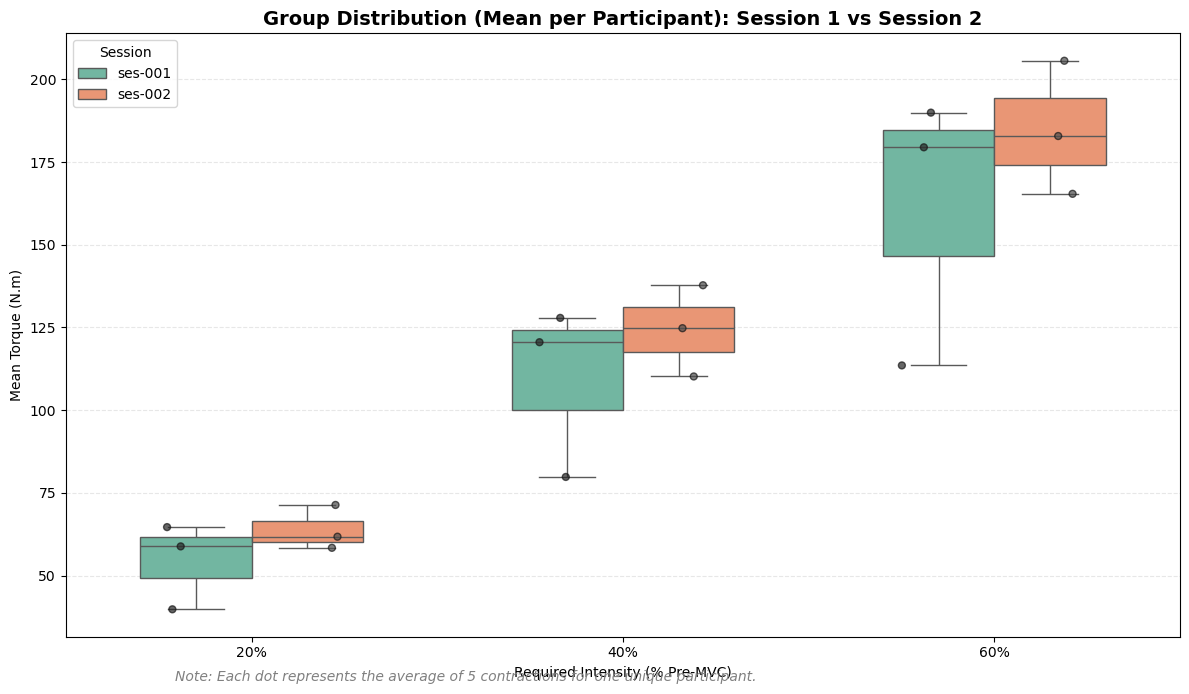

In [91]:
# --- 1. CONFIGURATION ---
base_dir = '/Users/hugoninho/Desktop/DigiMove/1st_bloc/Python-R-Git/Python /Data_Project_Valoxy/data/VALOXY-bids'
sessions = ['ses-001', 'ses-002']
fs = 500 
intensities = [20, 40, 60]

group_summary = []

# --- 2. DATA COLLECTION AND SUBJECT AVERAGING ---
subject_dirs = sorted(glob.glob(os.path.join(base_dir, 'sub-*')))

for sub_path in subject_dirs:
    sub_id = os.path.basename(sub_path)
    
    for ses_id in sessions:
        beh_folder = os.path.join(sub_path, ses_id, 'beh')
        torque_files = glob.glob(f"{beh_folder}/*torque_physio.tsv.gz")
        events_files = glob.glob(f"{beh_folder}/*events.tsv")

        if torque_files and events_files:
            try:
                torque_data = pd.read_csv(torque_files[0], sep='\t', compression='gzip')
                events_data = pd.read_csv(events_files[0], sep='\t')
                torque_data['time'] = np.arange(len(torque_data)) / fs
                torque_signal = torque_data.iloc[:, 0]

                for target in intensities:
                    reps = events_data[events_data['trial_type'].str.contains(f'Contraction_{target}_Rep', na=False)]
                    
                    if not reps.empty:
                        rep_means = []
                        for _, row in reps.iterrows():
                            mask = (torque_data['time'] >= row['onset']) & (torque_data['time'] <= row['onset'] + 10)
                            rep_means.append(torque_signal[mask].mean())
                        
                        # AVERAGING 5 REPS: One single value per subject/session/intensity
                        subject_condition_mean = np.mean(rep_means)
                        
                        group_summary.append({
                            'Subject': sub_id,
                            'Session': ses_id,
                            'Intensity': f'{target}%',
                            'Torque': subject_condition_mean
                        })
            except Exception as e:
                print(f"Error on {sub_id} {ses_id}: {e}")

df_group = pd.DataFrame(group_summary)

# --- 3. NORMALITY TESTS ON GROUP MEANS (SHAPIRO-WILK) ---
print("\n--- NORMALITY TESTS ON GROUP MEANS (SHAPIRO-WILK) ---")
normality_results = []

for ses in sessions:
    for target in [f'{i}%' for i in intensities]:
        # Filter: Testing the distribution of participant means
        group_data = df_group[(df_group['Session'] == ses) & (df_group['Intensity'] == target)]['Torque']
        
        if len(group_data) >= 3:
            stat, p_value = stats.shapiro(group_data)
            normality_results.append({
                'Session': ses,
                'Intensity': target,
                'N_Subjects': len(group_data),
                'p-value': round(p_value, 4),
                'Normal': 'Yes' if p_value > 0.05 else 'No'
            })

df_normality = pd.DataFrame(normality_results)
print(df_normality.to_string(index=False))

# --- 4. GROUP DISTRIBUTION VISUALIZATION ---
plt.figure(figsize=(12, 7))

# Boxplot: shows the distribution of participant means
sns.boxplot(x='Intensity', y='Torque', hue='Session', data=df_group, palette='Set2', width=0.6)

# Stripplot: each dot is NOW a unique participant
sns.stripplot(x='Intensity', y='Torque', hue='Session', data=df_group, 
              dodge=True, color='.3', alpha=0.7, linewidth=1, edgecolor='gray', legend=False)

plt.title('Group Distribution (Mean per Participant): Session 1 vs Session 2', fontsize=14, fontweight='bold')
plt.xlabel('Required Intensity (% Pre-MVC)')
plt.ylabel('Mean Torque (N.m)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adding an informative note
plt.figtext(0.15, 0.02, "Note: Each dot represents the average of 5 contractions for one unique participant.", 
            fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.show()

### Preliminary Normality Assessment
In this section, we conduct a **Shapiro-Wilk test** to evaluate the data distribution for each intensity level and session. 

> **Important Note**: While assessing normality is a prerequisite for selecting appropriate downstream statistical tests (e.g., parametric vs. non-parametric), it is **not the primary focus of today’s analysis**. 
>
> These results are recorded here for documentation purposes and will be fully utilized in future sessions to justify the use of **Bland-Altman** plots and **ICC** calculations in R. For now, we are focusing on data consolidation and visual inspection.